<a href="https://colab.research.google.com/github/ana-luiza-lima/analise-churn-telecom/blob/main/ProjetoParteIII%2BMattiadeLima.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Análise de dados sobre cancelamento de clientes de Telecomunicações

O conjunto de dados analisado neste projeto representa informações reais e simuladas de clientes de uma empresa de telecomunicações, com o objetivo de investigar o comportamento de cancelamento de serviços (churn). A base conta com 7.032 registros, cada um representando um cliente, e traz variáveis demográficas, contratuais, financeiras e de feedback, oferecendo um panorama completo sobre o relacionamento desses clientes com a empresa.

Entre as variáveis presentes estão: tempo como cliente (em meses), valor mensal da fatura, valor total já pago, tipo de contrato (mensal, anual, bienal), forma de pagamento, presença de dependentes, se o cliente é idoso ou não, e se utiliza serviços como internet, suporte técnico, TV, entre outros. Também há colunas relacionadas à experiência do cliente, como o sentimento (análise de texto com valor de -1 a 1) e o tamanho do feedback fornecido.

O objetivo central deste trabalho é entender quais fatores estão mais associados à decisão do cliente de cancelar ou não os serviços, identificada pela variável binária de churn. Para isso, foram levantadas três hipóteses principais: (1) clientes com mais tempo na base cancelam menos; (2) valores mensais mais altos aumentam a chance de cancelamento; e (3) o tipo de contrato influencia diretamente na retenção.

Além de fornecer insights sobre comportamento do consumidor, este dataset pode ser útil em modelos de machine learning para previsão de churn, ações de retenção, ou ainda para melhorias nos processos de atendimento e contratação de serviços. As visualizações e análises numéricas conduzidas ao longo deste trabalho foram pensadas para verificar essas hipóteses e gerar uma base sólida para interpretações mais aprofundadas.

In [ ]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "telco_prep.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "beatafaron/telco-customer-churn-realistic-customer-feedback",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

/tmp/ipython-input-2-467694994.py:10: DeprecationWarning: load_dataset is deprecated and will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 5.55M/5.55M [00:01<00:00, 3.48MB/s]


First 5 records:    Unnamed: 0  customerID  gender  SeniorCitizen Partner Dependents  tenure  \
0           0  7590-vhveg  female              0     yes         no       1   
1           1  5575-gnvde    male              0      no         no      34   
2           2  3668-qpybk    male              0      no         no       2   
3           3  7795-cfocw    male              0      no         no      45   
4           4  9237-hqitu  female              0      no         no       2   

  PhoneService     MultipleLines InternetService  ...        Contract  \
0           no  no phone service             dsl  ...  month-to-month   
1          yes                no             dsl  ...        one year   
2          yes                no             dsl  ...  month-to-month   
3           no  no phone service             dsl  ...        one year   
4          yes                no     fiber optic  ...  month-to-month   

  PaperlessBilling              PaymentMethod MonthlyCharges TotalCha

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import cm

In [ ]:
print(f"O dataset tem {df.shape[0]} linhas e {df.shape[1]} colunas.")

O dataset tem 7032 linhas e 26 colunas.


In [ ]:
pd.set_option('display.max_columns', None) #Para mostrar todas as colunas
df.head()

,Unnamed: 0,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,PromptInput,CustomerFeedback,feedback_length,sentiment
0,0,7590-vhveg,female,0,yes,no,1,no,no phone service,dsl,no,yes,no,no,no,no,month-to-month,yes,electronic check,29.85,29.85,0,write a realistic customer feedback based on t...,i have been using the dsl internet service fro...,401,0.129545
1,1,5575-gnvde,male,0,no,no,34,yes,no,dsl,yes,no,yes,no,no,no,one year,no,mailed check,56.95,1889.50,0,write a realistic customer feedback based on t...,i have been a customer with this company for o...,399,0.170833
2,2,3668-qpybk,male,0,no,no,2,yes,no,dsl,yes,yes,no,no,no,no,month-to-month,yes,mailed check,53.85,108.15,1,write a realistic customer feedback based on t...,i recently signed up for dsl internet service ...,482,-0.228571
3,3,7795-cfocw,male,0,no,no,45,no,no phone service,dsl,yes,no,yes,yes,no,no,one year,no,bank transfer (automatic),42.30,1840.75,0,write a realistic customer feedback based on t...,i have been a loyal customer with this company...,406,0.215801
4,4,9237-hqitu,female,0,no,no,2,yes,no,fiber optic,no,no,no,no,no,no,month-to-month,yes,electronic check,70.70,151.65,1,write a realistic customer feedback based on t...,i recently switched to this fiber optic intern...,418,0.030000


In [ ]:
#Remover coluna Unnamed
df = df.drop(columns=['Unnamed: 0'])


In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,feedback_length,sentiment
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441,0.265785,460.670080,0.175450
std,0.368844,24.545260,30.085974,2266.771362,0.441782,68.164461,0.128033
min,0.000000,1.000000,18.250000,18.800000,0.000000,277.000000,-0.312500
25%,0.000000,9.000000,35.587500,401.450000,0.000000,414.000000,0.103554
50%,0.000000,29.000000,70.350000,1397.475000,0.000000,454.000000,0.183333
75%,0.000000,55.000000,89.862500,3794.737500,1.000000,499.000000,0.260000
max,1.000000,72.000000,118.750000,8684.800000,1.000000,840.000000,0.725000


In [ ]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [ ]:
# Mostra a quantidade de valores únicos por coluna
print(df.nunique().sort_values())

gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
PhoneService           2
PaperlessBilling       2
Churn                  2
MultipleLines          3
TechSupport            3
StreamingTV            3
OnlineBackup           3
DeviceProtection       3
StreamingMovies        3
Contract               3
OnlineSecurity         3
InternetService        3
PaymentMethod          4
tenure                72
feedback_length      411
MonthlyCharges      1584
sentiment           2399
TotalCharges        6530
PromptInput         6824
customerID          7032
CustomerFeedback    7032
dtype: int64


In [ ]:
# Verificar se tem valores nulos
valores_nulos = df.isnull().sum()

valores_nulos = valores_nulos[valores_nulos > 0]

if valores_nulos.empty:
    print("✅ Nenhum valor nulo encontrado no dataset.")
else:
    print("⚠️ Colunas com valores nulos:")
    print(valores_nulos)

✅ Nenhum valor nulo encontrado no dataset.


In [ ]:
# Verificando se tem clientes duplicados
duplicatas = df.duplicated(subset='customerID').sum()

print(f"Total de duplicatas encontradas: {duplicatas}")

Total de duplicatas encontradas: 0


In [ ]:
# Verificando a distribuição da variável alvo Churn
churn_dist = df['Churn'].value_counts(normalize=True) * 100 # Proporção de clientes que cancelaram e não cancelaram
churn_dist.index = ['Não Cancelou', 'Cancelou']
print("Distribuição de Churn (%):")
print(churn_dist)

Distribuição de Churn (%):
Não Cancelou    73.421502
Cancelou        26.578498
Name: proportion, dtype: float64


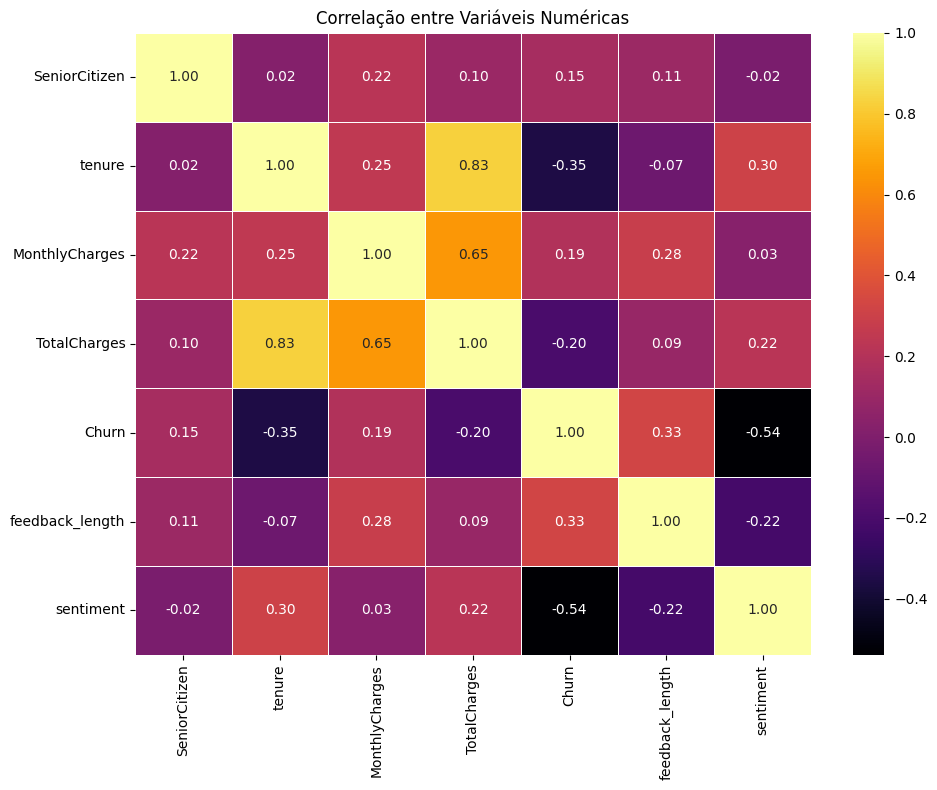

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Seleciona apenas as colunas numéricas
df_numericas = df.select_dtypes(include=['int64', 'float64'])

# Calcula a matriz de correlação
matriz_correlacao = df_numericas.corr()

# Cria o heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_correlacao, annot=True, fmt=".2f", cmap="inferno", linewidths=0.5)

plt.title("Correlação entre Variáveis Numéricas")
plt.tight_layout()
plt.show()


/tmp/ipython-input-14-3576969013.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="Churn", y="sentiment", palette="inferno")


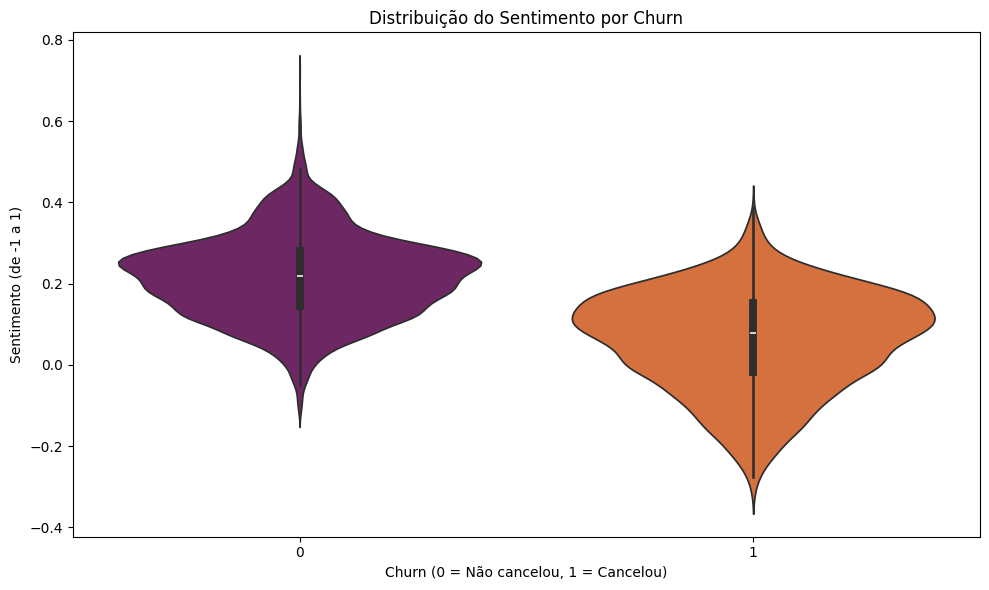

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Cria o gráfico de violino para sentimento por churn
sns.violinplot(data=df, x="Churn", y="sentiment", palette="inferno")

plt.title("Distribuição do Sentimento por Churn")
plt.xlabel("Churn (0 = Não cancelou, 1 = Cancelou)")
plt.ylabel("Sentimento (de -1 a 1)")
plt.tight_layout()
plt.show()


## Hipóteses:

Nos gráficos acima já vimos a relação direta entre o sentimento do cliente e o cancelamento, quanto mais insatisfeito, mas a chance de cancelar, agora vamos testar 3 novas hipóteses:

1. Clientes com contratos mais longos cancelam menos?
 - Quanto maior o 'tenure' (tempo como cliente), menor a chance de churn = 1.

2. Clientes com cobranças mensais mais altas tendem a cancelar mais?
 - Hipótese: MonthlyCharges está positivamente correlacionado com o churn.

3. O tipo de contrato influencia no churn?
 - Hipótese: clientes com contratos mensais (Contract) têm maior taxa de churn do que os com contrato anual.


**Hipótese 1**

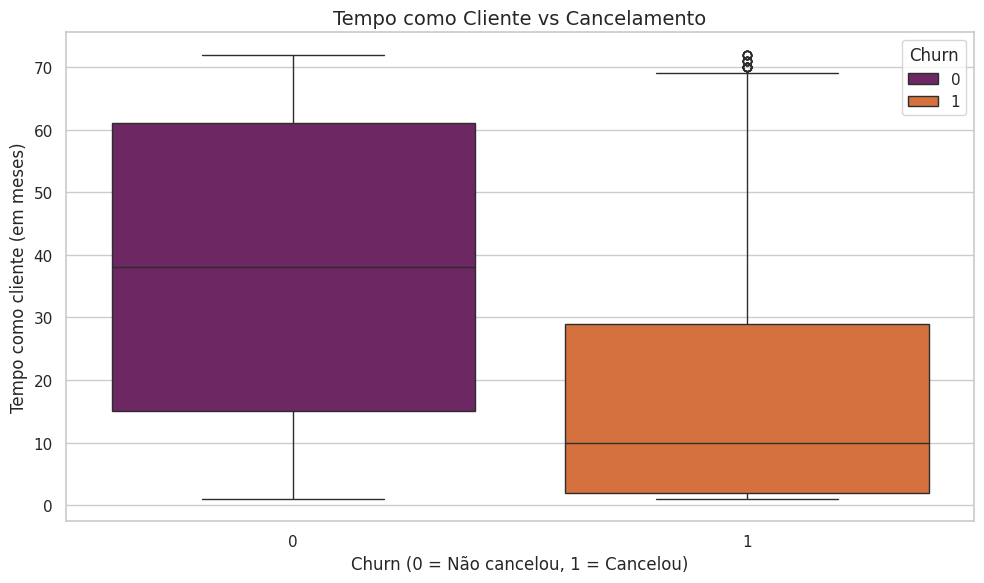

In [ ]:
# Estilo visual do gráfico
sns.set(style="whitegrid")

plt.figure(figsize=(10, 6))  # Define o tamanho do gráfico
sns.boxplot(x="Churn", y="tenure", data=df, hue="Churn", palette="inferno")  # Cria o boxplot

# Adiciona título e rótulos dos eixos
plt.title("Tempo como Cliente vs Cancelamento", fontsize=14)
plt.xlabel("Churn (0 = Não cancelou, 1 = Cancelou)")
plt.ylabel("Tempo como cliente (em meses)")

plt.tight_layout()
plt.show()

In [ ]:
# Calcula estatísticas descritivas do tempo como cliente (tenure) para cada grupo de Churn
df.groupby("Churn")["tenure"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
0,5163.0,37.650010,24.076940,1.0,15.0,38.0,61.0,72.0
1,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


Hipótese 2

/tmp/ipython-input-17-2155935369.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("inferno")


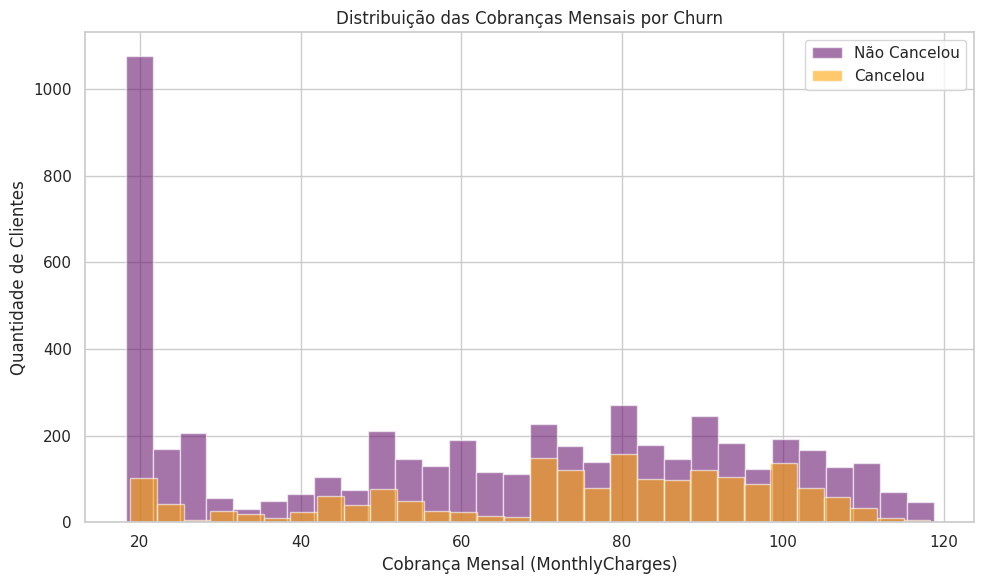

In [ ]:
# Cria o histograma para cada grupo
plt.figure(figsize=(10, 6))

# Pega duas cores da paleta "inferno"
cmap = cm.get_cmap("inferno")
cor_nao_cancelou = cmap(0.3)  # tom mais claro
cor_cancelou = cmap(0.8)      # tom mais escuro

# Clientes que não cancelaram (Churn = 0)
plt.hist(df[df['Churn'] == 0]['MonthlyCharges'], bins=30, alpha=0.6, label='Não Cancelou', color=cor_nao_cancelou)

# Clientes que cancelaram (Churn = 1)
plt.hist(df[df['Churn'] == 1]['MonthlyCharges'], bins=30, alpha=0.6, label='Cancelou', color=cor_cancelou)

# Títulos e legendas
plt.title('Distribuição das Cobranças Mensais por Churn')
plt.xlabel('Cobrança Mensal (MonthlyCharges)')
plt.ylabel('Quantidade de Clientes')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Calcula estatísticas descritivas do MonthlyCharges por grupo de Churn
df.groupby("Churn")["MonthlyCharges"].describe()



,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
0,5163.0,61.307408,31.094557,18.25,25.10,64.45,88.475,118.75
1,1869.0,74.441332,24.666053,18.85,56.15,79.65,94.200,118.35


Hipótese 3

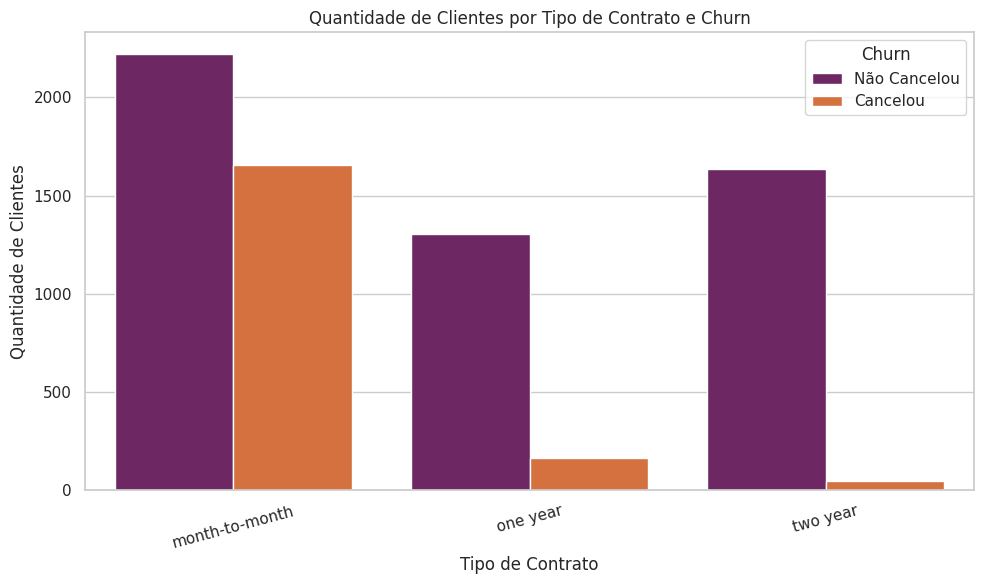

In [ ]:
plt.figure(figsize=(10, 6))

# Gráfico de barras: quantidade de clientes por tipo de contrato, separado por churn
sns.countplot(data=df, x="Contract", hue="Churn", palette="inferno")

plt.title("Quantidade de Clientes por Tipo de Contrato e Churn")
plt.xlabel("Tipo de Contrato")
plt.ylabel("Quantidade de Clientes")
plt.legend(title="Churn", labels=["Não Cancelou", "Cancelou"])
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [ ]:
taxa_churn_por_contrato = df.groupby("Contract")["Churn"].mean() * 100
taxa_churn_por_contrato = taxa_churn_por_contrato.round(2)
print(taxa_churn_por_contrato)

Contract
month-to-month    42.71
one year          11.28
two year           2.85
Name: Churn, dtype: float64


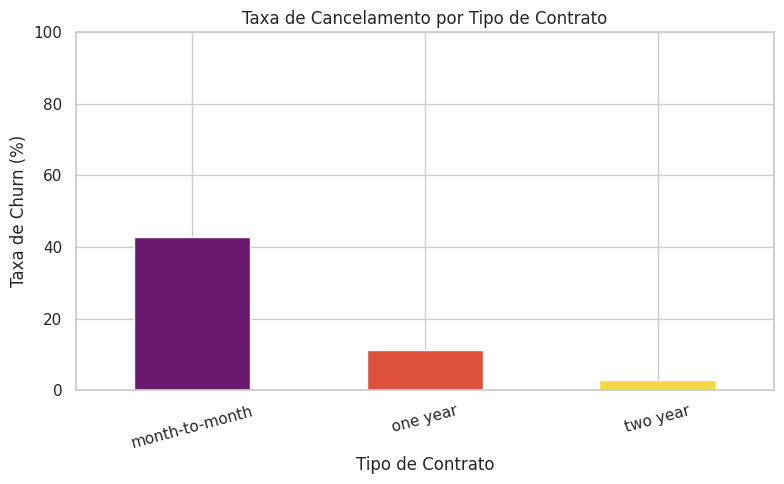

In [ ]:
# Cria o gráfico com as taxas já calculadas
plt.figure(figsize=(8, 5))
taxa_churn_por_contrato.plot(kind='bar', color=cm.inferno([0.3, 0.6, 0.9]))

plt.title("Taxa de Cancelamento por Tipo de Contrato")
plt.ylabel("Taxa de Churn (%)")
plt.xlabel("Tipo de Contrato")
plt.xticks(rotation=15)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()


# Resultado:

No boxplot conseguimos observar a relação entre o tempo de base e o cancelamento, sendo que em clientes que não cancelaram a mediana era de aproximadamente 38 meses, ao contrário dos que cancelaram em que a mediana era de 10 meses. Então, quanto maior o tempo como cliente, menor a chance de churn.
Já no histograma da hipótese dois, vemos que clientes que cancelaram tendem a ter valores mensais maiores, sugerindo uma possível associação entre mensalidades elevadas e churn.
E por fim, concluímos que contratos mensagem têm muito mais chance de cancelamentos do que contratos de 1 ou 2 anos, reforçando que contratos mais longos podem ajudar na retenção de clientes.

## Modelagem

In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import LabelEncoder

# Separa X e y
X = df.drop(['Churn', 'customerID', 'PromptInput'], axis=1).copy()  # Faz uma cópia segura
y = df['Churn']

# Codifica colunas categóricas
le = LabelEncoder()
for col in X.select_dtypes(include='object').columns:
    X[col] = le.fit_transform(X[col])

# Aplica SelectKBest
selector = SelectKBest(score_func=f_classif, k=10)
X_new = selector.fit_transform(X, y)

# Seleciona nomes das melhores features
selected_features = X.columns[selector.get_support()]
print("Melhores features selecionadas:", selected_features.tolist())




Melhores features selecionadas: ['tenure', 'OnlineSecurity', 'OnlineBackup', 'TechSupport', 'Contract', 'MonthlyCharges', 'TotalCharges', 'CustomerFeedback', 'feedback_length', 'sentiment']


In [ ]:
# Verifica se ainda há colunas com tipo 'object' (string ou categórica não convertida)
print(X.dtypes[X.dtypes == 'object'])


Series([], dtype: object)


In [ ]:
# Filtra X para manter apenas as colunas selecionadas
X = X[selected_features]


In [ ]:
from sklearn.model_selection import train_test_split

# Seleciona apenas as colunas escolhidas pelo SelectKBest
X_selected = X[selected_features]

# Divide os dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.3, random_state=42
)


In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Cria e treina o modelo
modelo = DecisionTreeClassifier(random_state=42)
modelo.fit(X_train, y_train)


DecisionTreeClassifier(random_state=42)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Faz previsões com os dados de teste
y_pred = modelo.predict(X_test)

# Calcula as métricas
print("Acurácia:", accuracy_score(y_test, y_pred))
print("Precisão:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

# Matriz de confusão
print("\nMatriz de Confusão:")
print(confusion_matrix(y_test, y_pred))


Acurácia: 0.9260663507109005
Precisão: 0.8667883211678832
Recall: 0.8512544802867383
F1 Score: 0.8589511754068716

Matriz de Confusão:
[[1479   73]
 [  83  475]]
